In [1]:
import sys, os
from pathlib import Path

PROJECT      = "/kaggle/working"
L2A_SRC      = "/kaggle/input/datasets/surathbob/hiwaf-l2a-v1"
L2B_SRC      = "/kaggle/input/datasets/surathbob/hiwaf-l2b-v1"
SPLIT_SRC    = "/kaggle/input/datasets/surathbob/hiwaf-split-v1"

sys.path.insert(0, PROJECT)
sys.path.insert(0, SPLIT_SRC)   # feature_engineering/
os.chdir(PROJECT)
Path("results").mkdir(exist_ok=True)

print(f"Working dir: {os.getcwd()}")

Working dir: /kaggle/working


In [2]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import time, re, json
import scipy.special
from pathlib import Path
from sklearn.metrics import confusion_matrix

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES, strip_to_path_query
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

# ── L2A ──────────────────────────────────────────────────────────────────
l2a_metadata = json.load(open(f"{L2A_SRC}/exported_models/layer2a_metadata.json"))
l2a_winner   = l2a_metadata["winner"]
l2a_onnx_name = ("layer2a_shallow_autoencoder.onnx" if l2a_winner == "Shallow Autoencoder"
                  else "layer2a_isolation_forest.onnx")
l2a_sess = ort.InferenceSession(f"{L2A_SRC}/exported_models/{l2a_onnx_name}")
norm     = Normalizer.load(f"{SPLIT_SRC}/exported_models/scaler_l2a.pkl")

l2a_key = "shallow_autoencoder" if l2a_winner == "Shallow Autoencoder" else "isolation_forest"
L2A_THRESHOLD = l2a_metadata[l2a_key]["threshold"]
l2a_input_name = l2a_sess.get_inputs()[0].name

# ── L2B ──────────────────────────────────────────────────────────────────
l2b_metadata = json.load(open(f"{L2B_SRC}/exported_models/layer2b_metadata.json"))
l2b_sess = ort.InferenceSession(f"{L2B_SRC}/exported_models/layer2b_bigru.onnx")
tok      = CharTokenizer(max_len=512)

print(f"✅ L2A: {l2a_winner:<25} input='{l2a_input_name}'  threshold={L2A_THRESHOLD:.6f}")
print(f"✅ L2B: {l2b_metadata['headline_model']} (fixed headline)  sweep_point='{l2b_metadata['selected_sweep_point']}'")

[Normalizer] Loaded from /kaggle/input/datasets/surathbob/hiwaf-split-v1/exported_models/scaler_l2a.pkl
✅ L2A: Shallow Autoencoder       input='input'  threshold=0.002985
✅ L2B: BiGRU (fixed headline)  sweep_point='8k'


In [4]:
# CHANGED: L1 rules reuse the SAME regexes extract_features() uses
# internally, rather than a hand-copied, drifted duplicate. Import the
# compiled patterns directly instead of re-writing them.
from feature_engineering.extractor import _SQLI, _XSS, _LFI, _OSCI

def layer1_check(url: str, body: str) -> tuple:
    """
    Returns (blocked: bool, reason: str). Regex-only — rate limiting is
    excluded here since it requires sequential request history and isn't
    meaningful for i.i.d. single-request test-set evaluation. Noted
    explicitly rather than silently omitted.
    """
    txt = url + " " + body
    if _SQLI.search(txt): return True, "sqli_rule"
    if _XSS.search(txt):  return True, "xss_rule"
    if _LFI.search(txt):  return True, "lfi_rule"
    if _OSCI.search(txt): return True, "other_attack_rule"   # CHANGED: was "cmdi_rule"
    return False, ""

print("✅ Layer 1 rules loaded (shared regex source with extract_features())")
tests = [
    ("/?id=1 UNION SELECT * FROM users", "", True),
    ("<script>alert(1)</script>",          "", True),
    ("/../../../etc/passwd",               "", True),
    ("/api/products?cat=shoes",            "", False),
]
print("  Smoke tests:")
for url, body, expected in tests:
    result, reason = layer1_check(url, body)
    status = "✅" if result == expected else "❌"
    print(f"    {status} {url[:40]:<40} blocked={result}")

✅ Layer 1 rules loaded (shared regex source with extract_features())
  Smoke tests:
    ✅ /?id=1 UNION SELECT * FROM users         blocked=True
    ✅ <script>alert(1)</script>                blocked=True
    ✅ /../../../etc/passwd                     blocked=True
    ✅ /api/products?cat=shoes                  blocked=False


In [5]:
# CHANGED: threat-score coefficients are now named constants, not magic
# numbers buried in the function — makes the Priority C sensitivity sweep
# (R2 Issue 6: 30/70 boundaries, x15/x50 coefficients) a config change,
# not a code edit.
L2A_SCORE_MULTIPLIER = 15.0   # l2a_contrib = min(50, l2a_score * L2A_SCORE_MULTIPLIER)
L2B_CONF_MULTIPLIER  = 50.0   # l2b_contrib = pred_conf * L2B_CONF_MULTIPLIER (0 if predicted normal)
LOG_THRESHOLD   = 30
BLOCK_THRESHOLD = 70

def run_pipeline(
    request: dict,
    l2a_threshold=L2A_THRESHOLD,
    l2a_mult=L2A_SCORE_MULTIPLIER,
    l2b_mult=L2B_CONF_MULTIPLIER,
    log_thr=LOG_THRESHOLD,
    block_thr=BLOCK_THRESHOLD,
) -> dict:
    """Full WAF pipeline: L1 -> L2A -> L2B -> Threat Score. Threat score
    formula fixed per accepted paper: s = min(100, c_L2A + c_L2B)."""
    url  = str(request.get("url",  ""))
    body = str(request.get("body", ""))
    t0   = time.perf_counter()

    l1_blocked, l1_reason = layer1_check(url, body)
    if l1_blocked:
        return {
            "layer": "L1",
            "decision": "block",
            "score": 100,
            "label": l1_reason,
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
    
            # ML layers were never executed
            "l2a_score": None,
            "l2a_contrib": None,
            "l2b_contrib": None,
        }

    features = extract_features(request)
    fvec     = norm.transform(to_vector(features)).astype(np.float32)

    if l2a_winner == "Shallow Autoencoder":
        recon     = l2a_sess.run(None, {l2a_input_name: fvec})[0]
        l2a_score = float(np.mean((fvec - recon) ** 2))
    else:
        l2a_score = float(-l2a_sess.run(None, {l2a_input_name: fvec})[0][0])

    if l2a_score < l2a_threshold:
        return {
            "layer": "L2A", "decision": "allow", "score": 0, "label": "normal",
            "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
            "l2a_score": round(l2a_score, 6),
            "l2a_contrib": 0.0, "l2b_contrib": 0.0,
        }

    tokens = tok.encode_request(request).reshape(1, -1).astype(np.int64)
    logits = l2b_sess.run(None, {"token_ids": tokens})[0][0]

    proba      = scipy.special.softmax(logits)
    pred_cls   = int(np.argmax(proba))
    pred_conf  = float(proba[pred_cls])
    pred_label = CLASS_NAMES[pred_cls]

    l2a_contrib  = min(50.0, l2a_score * l2a_mult)
    l2b_contrib  = 0.0 if pred_cls == 0 else pred_conf * l2b_mult
    threat_score = min(100, int(l2a_contrib + l2b_contrib))

    if threat_score >= block_thr:  decision = "block"
    elif threat_score >= log_thr:  decision = "log"
    else:                          decision = "allow"

    return {
        "layer": "L2B", "decision": decision, "score": threat_score, "label": pred_label,
        "confidence": round(pred_conf, 4),
        "l2a_score": round(l2a_score, 6),
        "l2a_contrib": round(l2a_contrib, 2), "l2b_contrib": round(l2b_contrib, 2),
        "latency_ms": round((time.perf_counter() - t0) * 1000, 3),
    }

print("✅ Pipeline function ready")

✅ Pipeline function ready


In [6]:
from tqdm import tqdm

# CHANGED: uses l2b_test_raw.csv directly — the exact same 3,693 rows that
# produced l2b_test_X_numeric.npy/l2b_test_y.npy, verified aligned in
# Notebook 02's addendum. NOT a fresh re-split (the old notebook's bug).
test_df = pd.read_csv(f"{SPLIT_SRC}/data/splits/l2b_test_raw.csv")
print(f"Test set: {len(test_df):,} requests (family-aware, verified-aligned)")
print(test_df["attack_class"].value_counts())

results_list = []
errors = 0
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Running WAF pipeline"):
    req = {
        "url": str(row.get("url", "")), "method": str(row.get("method", "GET")),
        "headers": {}, "body": str(row.get("body", "")),
    }
    try:
        res = run_pipeline(req)
        res["true_label"]    = row["attack_class"]
        res["true_label_id"] = row["attack_class_id"]
        results_list.append(res)
    except Exception as e:
        errors += 1
        if errors <= 3:
            print(f"  Error: {e}")

df_results = pd.DataFrame(results_list)
if errors > 0:
    print(f"  ⚠️  {errors} requests errored and were skipped")

print(f"\n--- Pipeline decisions ---\n{df_results['decision'].value_counts().to_string()}")
print(f"\n--- Layer routing ---\n{df_results['layer'].value_counts().to_string()}")
print(f"\nMean latency: {df_results['latency_ms'].mean():.3f}ms")

Test set: 3,693 requests (family-aware, verified-aligned)
attack_class
sqli            1929
normal           603
lfi              447
other_attack     434
xss              280
Name: count, dtype: int64


Running WAF pipeline: 100%|██████████| 3693/3693 [00:09<00:00, 372.80it/s] 


--- Pipeline decisions ---
decision
block    2155
allow    1132
log       406

--- Layer routing ---
layer
L1     2118
L2A    1105
L2B     470

Mean latency: 2.540ms


In [7]:
# DECISION: "block" AND "log" both count as "detected" for TPR/FPR purposes
# — "log" is a real signal (score 30-69), not a miss. A normal request that
# gets logged is still a false positive; an attack that gets logged is
# still detected, just not blocked outright. Reported both ways below so
# the choice is visible, not hidden in one number.

y_true = (df_results["true_label_id"] > 0).astype(int)

for tier_name, positive_decisions in [
    ("block only",        {"block"}),
    ("block + log",       {"block", "log"}),
]:
    y_pred = df_results["decision"].isin(positive_decisions).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    acc  = (tp + tn) / len(y_true)

    print(f"=== END-TO-END RESULTS ({tier_name} = positive) ===")
    print(f"  Accuracy:  {acc:.4f}   Detection(TPR): {tpr:.4f}   FPR: {fpr:.4f}   Precision: {prec:.4f}")
    print(f"  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}\n")

=== END-TO-END RESULTS (block only = positive) ===
  Accuracy:  0.7468   Detection(TPR): 0.6974   FPR: 0.0000   Precision: 1.0000
  TP=2,155  FP=0  TN=603  FN=935

=== END-TO-END RESULTS (block + log = positive) ===
  Accuracy:  0.8568   Detection(TPR): 0.8288   FPR: 0.0000   Precision: 1.0000
  TP=2,561  FP=0  TN=603  FN=529



=== Latency — full pipeline (ms) ===
  Mean: 2.540  Median: 0.022  P95: 18.726  P99: 19.600  Max: 26.002
  Target: P99 < 20ms — PASS ✅

  Latency by layer:
    L2A: mean=0.49ms  p99=1.08ms  n=1,105
    L2B: mean=18.75ms  p99=23.73ms  n=470
    L1: mean=0.01ms  p99=0.07ms  n=2,118


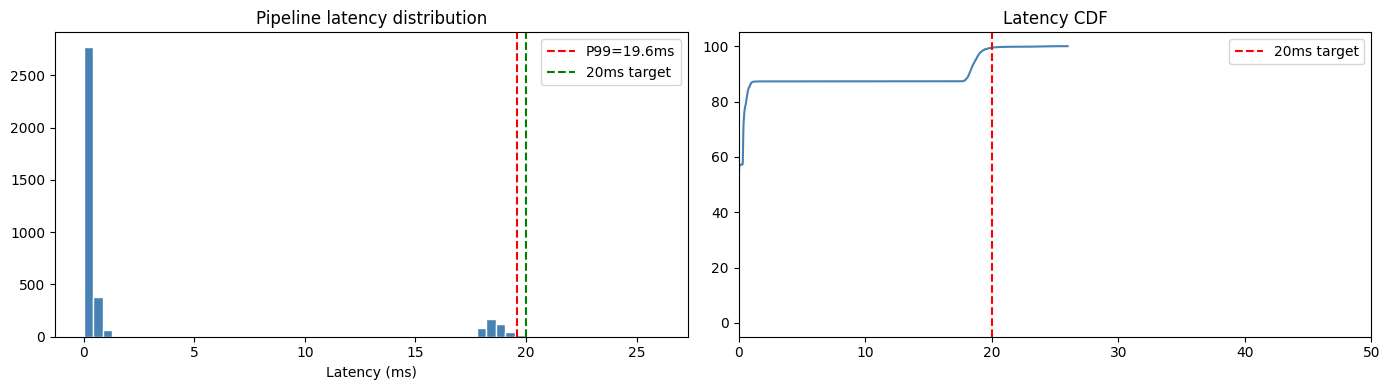

In [8]:
lat = df_results["latency_ms"]
print("=== Latency — full pipeline (ms) ===")
print(f"  Mean: {lat.mean():.3f}  Median: {lat.median():.3f}  P95: {lat.quantile(0.95):.3f}  P99: {lat.quantile(0.99):.3f}  Max: {lat.max():.3f}")
print(f"  Target: P99 < 20ms — {'PASS ✅' if lat.quantile(0.99) <= 20 else f'WARN ⚠️ ({lat.quantile(0.99):.1f}ms)'}")

print("\n  Latency by layer:")
for layer in df_results["layer"].unique():
    sub = df_results[df_results["layer"] == layer]["latency_ms"]
    print(f"    {layer}: mean={sub.mean():.2f}ms  p99={sub.quantile(0.99):.2f}ms  n={len(sub):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lat.clip(0, 30), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(lat.quantile(0.99), color="red", linestyle="--", label=f"P99={lat.quantile(0.99):.1f}ms")
axes[0].axvline(20, color="green", linestyle="--", label="20ms target")
axes[0].set_xlabel("Latency (ms)"); axes[0].set_title("Pipeline latency distribution"); axes[0].legend()

sorted_lat = np.sort(lat.values)
cdf = np.arange(1, len(sorted_lat)+1) / len(sorted_lat)
axes[1].plot(sorted_lat, cdf * 100, color="steelblue")
axes[1].axvline(20, color="red", linestyle="--", label="20ms target")
axes[1].set_xlim(0, 50); axes[1].set_title("Latency CDF"); axes[1].legend()

plt.tight_layout()
plt.savefig("results/06_latency.png", dpi=120)
plt.show()

In [9]:
print("=== Detection by attack class (block-only) ===")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    cls_df   = df_results[df_results["true_label"] == cls]
    detected = (cls_df["decision"] == "block").sum()
    total    = len(cls_df)
    rate     = detected / total * 100 if total > 0 else 0
    status   = "✅" if rate >= 90 else "⚠️ "
    print(f"  {status} {cls:<15}: {detected:>5}/{total:<5}  ({rate:.1f}%)")

normal_df = df_results[df_results["true_label"] == "normal"]
fp_cnt = (normal_df["decision"] == "block").sum()
print(f"\nFalse positives (normal blocked): {fp_cnt}/{len(normal_df)} ({fp_cnt/len(normal_df)*100:.2f}%)")

print("\n=== Layer routing breakdown ===")
total_reqs = len(df_results)
labels = {"L1": "known attacks caught by rules", "L2A": "allowed as normal (below threshold)", "L2B": "anomalous — scored by BiGRU"}
for layer in ["L1", "L2A", "L2B"]:
    n = (df_results["layer"] == layer).sum()
    print(f"  {layer}: {n:,} ({n/total_reqs*100:.1f}%) — {labels[layer]}")

=== Detection by attack class (block-only) ===
  ✅ sqli           :  1812/1929   (93.9%)
  ⚠️  xss            :   248/280    (88.6%)
  ⚠️  lfi            :    52/447    (11.6%)
  ⚠️  other_attack   :    43/434    (9.9%)

False positives (normal blocked): 0/603 (0.00%)

=== Layer routing breakdown ===
  L1: 2,118 (57.4%) — known attacks caught by rules
  L2A: 1,105 (29.9%) — allowed as normal (below threshold)
  L2B: 470 (12.7%) — anomalous — scored by BiGRU


In [10]:
# Resolves R2 Critical Issue 1: a genuine Allow/Log/Block x ground-truth
# matrix from ONE pipeline run, not L2A FPR mixed with L2B accuracy/F1.
decision_order = ["allow", "log", "block"]
truth_order    = ["normal"] + [c for c in CLASS_NAMES if c != "normal"]

cm_unified = pd.crosstab(df_results["true_label"], df_results["decision"]).reindex(
    index=truth_order, columns=decision_order, fill_value=0)
print("Unified Confusion Matrix (ground truth x decision)")
print(cm_unified)
cm_unified.to_csv("results/06_unified_confusion_matrix.csv")

Unified Confusion Matrix (ground truth x decision)
decision      allow  log  block
true_label                     
normal          603    0      0
sqli              1  116   1812
xss               3   29    248
lfi             362   33     52
other_attack    163  228     43


In [11]:
df_results.to_csv("results/06_pipeline_results.csv", index=False)

y_pred_block_only = (df_results["decision"] == "block").astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_block_only, labels=[0, 1]).ravel()

final_report = {
    "test_set_size": len(df_results),
    "l1_block_pct": float((df_results["layer"] == "L1").mean() * 100),
    "end_to_end_accuracy": float((tp + tn) / len(y_true)),
    "detection_rate_block_only": float(tp / (tp + fn)) if (tp + fn) > 0 else None,
    "fpr_block_only": float(fp / (fp + tn)) if (fp + tn) > 0 else None,
    "precision_block_only": float(tp / (tp + fp)) if (tp + fp) > 0 else None,
    "mean_latency_ms": float(df_results["latency_ms"].mean()),
    "p99_latency_ms": float(df_results["latency_ms"].quantile(0.99)),
    "threat_score_coefficients": {
        "l2a_multiplier": L2A_SCORE_MULTIPLIER, "l2b_multiplier": L2B_CONF_MULTIPLIER,
        "log_threshold": LOG_THRESHOLD, "block_threshold": BLOCK_THRESHOLD,
    },
    "data_source": "l2b_test_raw.csv — verified-aligned family-aware test set (Notebook 02 addendum)",
}
with open("results/06_final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print(json.dumps(final_report, indent=2))

{
  "test_set_size": 3693,
  "l1_block_pct": 57.35174654752234,
  "end_to_end_accuracy": 0.7468183049011644,
  "detection_rate_block_only": 0.6974110032362459,
  "fpr_block_only": 0.0,
  "precision_block_only": 1.0,
  "mean_latency_ms": 2.540410777145952,
  "p99_latency_ms": 19.599999999999998,
  "threat_score_coefficients": {
    "l2a_multiplier": 15.0,
    "l2b_multiplier": 50.0,
    "log_threshold": 30,
    "block_threshold": 70
  },
  "data_source": "l2b_test_raw.csv \u2014 verified-aligned family-aware test set (Notebook 02 addendum)"
}


In [12]:
import random
import string
import pandas as pd

random.seed(42)

traffic = []

# ============================================================
# Helpers
# ============================================================

def rand_id():
    return random.randint(1, 5000)

def rand_page():
    return random.randint(1, 20)

def rand_email():
    names = ["john","alice","bob","emma","david","kevin","sarah","mike"]
    domains = ["gmail.com","yahoo.com","company.com","outlook.com"]
    return f"{random.choice(names)}{random.randint(1,999)}@{random.choice(domains)}"

def rand_product():
    return random.choice([
        "laptop","phone","mouse","keyboard","monitor",
        "camera","printer","router","speaker","ssd"
    ])

def rand_name():
    return random.choice([
        "john","alice","bob","emma","kevin","sarah",
        "michael","james","robert","david"
    ])

# ============================================================
# 1. BENIGN TRAFFIC (60)
# ============================================================

for _ in range(60):

    t = random.randint(1,12)

    if t == 1:
        url="/"

    elif t == 2:
        url=f"/products/{rand_id()}"

    elif t == 3:
        url=f"/products?category={rand_product()}&page={rand_page()}"

    elif t == 4:
        url=f"/search?q={rand_product()}"

    elif t == 5:
        url=f"/profile?id={rand_id()}"

    elif t == 6:
        url=f"/orders/{rand_id()}"

    elif t == 7:
        url=f"/blog/{random.choice(['security','technology','python','cloud'])}"

    elif t == 8:
        url="/login"

    elif t == 9:
        url="/signup"

    elif t == 10:
        url="/api/products?limit=20"

    elif t == 11:
        url="/cart"

    else:
        url="/checkout"

    body=""

    if url=="/login":
        body=f"email={rand_email()}&password=Password123"

    elif url=="/signup":
        body=f"name={rand_name()}&email={rand_email()}&password=StrongPass@123"

    traffic.append({
        "method":"GET" if body=="" else "POST",
        "url":url,
        "body":body,
        "true_label":"normal"
    })

# ============================================================
# 2. SQL Injection (25)
# ============================================================

sqli_payloads=[
"1' OR '1'='1",
"1 OR 1=1",
"' UNION SELECT username,password FROM users--",
"' UNION ALL SELECT NULL,NULL--",
"' WAITFOR DELAY '0:0:5'--",
"' OR SLEEP(5)--",
"' OR benchmark(1000000,sha1(1))--",
"' AND extractvalue(1,concat(0x7e,user()))--",
"' AND updatexml(1,concat(0x7e,database()),1)--",
"' OR EXISTS(SELECT * FROM users)--"
]

for _ in range(25):
    traffic.append({
        "method":"GET",
        "url":f"/search?q={random.choice(sqli_payloads)}",
        "body":"",
        "true_label":"sqli"
    })

# ============================================================
# 3. XSS (20)
# ============================================================

xss_payloads=[
"<script>alert(1)</script>",
"<img src=x onerror=alert(1)>",
"<svg/onload=alert(1)>",
"<iframe src=javascript:alert(1)>",
"<body onload=alert(1)>",
"<object data=javascript:alert(1)>",
"<video><source onerror=alert(1)>",
"<details open ontoggle=alert(1)>",
"<marquee onstart=alert(1)>",
"<input autofocus onfocus=alert(1)>"
]

for _ in range(20):
    traffic.append({
        "method":"GET",
        "url":f"/comment?text={random.choice(xss_payloads)}",
        "body":"",
        "true_label":"xss"
    })

# ============================================================
# 4. LFI (15)
# ============================================================

lfi_payloads=[
"../../../../etc/passwd",
"../../../../etc/shadow",
"..\\..\\..\\windows\\win.ini",
"..\\..\\boot.ini",
"../../proc/self/environ",
"../../../../var/log/auth.log",
"../../../etc/hosts",
"../../../../etc/group"
]

for _ in range(15):
    traffic.append({
        "method":"GET",
        "url":f"/download?file={random.choice(lfi_payloads)}",
        "body":"",
        "true_label":"lfi"
    })

# ============================================================
# 5. OTHER ATTACK (15)
# ============================================================

other_samples=[
("/cmd","cmd=cat /etc/passwd"),
("/cmd","cmd=id"),
("/cmd","cmd=whoami"),
("/upload","filename=shell.php"),
("/upload","filename=exploit.jsp"),
("/admin","username=admin&password=admin"),
("/admin","username=root&password=root"),
("/exec","command=netstat -an"),
("/exec","command=uname -a"),
("/config","debug=true")
]

for _ in range(15):
    u,b=random.choice(other_samples)

    traffic.append({
        "method":"POST",
        "url":u,
        "body":b,
        "true_label":"other_attack"
    })

# ============================================================
# 6. SSRF (5)
# ============================================================

ssrf=[
"/fetch?url=http://169.254.169.254/latest/meta-data/",
"/proxy?url=http://127.0.0.1:8080/admin",
"/import?src=http://localhost:9200/_cat",
"/?next=http://0.0.0.0/admin",
"/webhook?callback=http://169.254.169.254/latest/meta-data/"
]

for u in ssrf:
    traffic.append({
        "method":"GET",
        "url":u,
        "body":"",
        "true_label":"ssrf"
    })

# ============================================================
# 7. GraphQL Injection (5)
# ============================================================

graphql=[
'{"query":"{ __schema { types { name } } }"}',
'{"query":"query { users(first:999999){edges{node{id}}} }"}',
'{"query":"mutation { deleteUser(id:\\"1 OR 1=1\\"){success} }"}',
'{"query":"{ user(id:\\"1);DROP TABLE users;--\\"){id} }"}',
'{"query":"query{__type(name:\\"User\\"){fields{name}}}"}'
]

for q in graphql:
    traffic.append({
        "method":"POST",
        "url":"/graphql",
        "body":q,
        "true_label":"graphql"
    })

# ============================================================
# 8. API Abuse (3)
# ============================================================

api=[
"/api/orders?limit=999999",
"/api/export?table=users&all=true",
"/api/users?fields=password,ssn,apikey"
]

for u in api:
    traffic.append({
        "method":"GET",
        "url":u,
        "body":"",
        "true_label":"api_abuse"
    })

# ============================================================
# 9. Deserialization (2)
# ============================================================

deser=[
'O:8:"stdClass":1:{s:4:"data";s:6:"whoami";}',
'!!python/object/apply:os.system ["id"]'
]

for d in deser:
    traffic.append({
        "method":"POST",
        "url":"/api/import",
        "body":d,
        "true_label":"deserialization"
    })

# ============================================================
# Shuffle
# ============================================================

random.shuffle(traffic)

df_fresh = pd.DataFrame(traffic)

print(df_fresh.true_label.value_counts())

df_fresh.head()

true_label
normal             60
sqli               25
xss                20
lfi                15
other_attack       15
graphql             5
ssrf                5
api_abuse           3
deserialization     2
Name: count, dtype: int64


,method,url,body,true_label
0,GET,/download?file=../../../../etc/group,,lfi
1,GET,/profile?id=4563,,normal
2,GET,/download?file=..\..\boot.ini,,lfi
3,GET,/comment?text=<body onload=alert(1)>,,xss
4,POST,/graphql,"{""query"":""query{__type(name:\""User\""){fields{n...",graphql


In [13]:
from tqdm import tqdm

results = []

for _, row in tqdm(df_fresh.iterrows(), total=len(df_fresh)):
    req = {
        "method":"GET",
        "url":row.url,
        "body":row.body
    }

    out = run_pipeline(req)

    out["true_label"] = row.true_label

    results.append(out)

df_pipeline = pd.DataFrame(results)

print(df_pipeline.head())

100%|██████████| 150/150 [00:01<00:00, 90.57it/s] 

  layer decision  score         label  latency_ms  l2a_score  l2a_contrib  \
0    L1    block    100      lfi_rule       0.032        NaN          NaN   
1   L2B    allow      0        normal      21.400   0.040097         0.60   
2    L1    block    100      lfi_rule       0.034        NaN          NaN   
3    L1    block    100      xss_rule       0.014        NaN          NaN   
4   L2B      log     63  other_attack      19.218   0.970450        14.56   

   l2b_contrib true_label  confidence  
0          NaN        lfi         NaN  
1         0.00     normal      1.0000  
2          NaN        lfi         NaN  
3          NaN        xss         NaN  
4        49.44    graphql      0.9888  


In [14]:
print("="*60)
print("Fresh Traffic Evaluation")
print("="*60)

print("\nDecision Distribution")
print(df_pipeline.decision.value_counts())

print("\nLayer Routing")
print(df_pipeline.layer.value_counts())

print("\nMean Latency")
print(df_pipeline.latency_ms.mean())

summary = (
    df_pipeline
    .groupby("true_label")
    .agg(
        Requests=("decision","count"),
        Block=("decision",lambda x:(x=="block").sum()),
        Log=("decision",lambda x:(x=="log").sum()),
        Allow=("decision",lambda x:(x=="allow").sum())
    )
)

summary["Block %"] = summary.Block/summary.Requests*100
summary["Log %"] = summary.Log/summary.Requests*100
summary["Allow %"] = summary.Allow/summary.Requests*100

summary

Fresh Traffic Evaluation

Decision Distribution
decision
block    68
allow    47
log      35
Name: count, dtype: int64

Layer Routing
layer
L2B    82
L1     68
Name: count, dtype: int64

Mean Latency
10.707986666666665


,Requests,Block,Log,Allow,Block %,Log %,Allow %
true_label,,,,,,,
api_abuse,3,0,0,3,0.0,0.000000,100.000000
deserialization,2,1,1,0,50.0,50.000000,0.000000
graphql,5,2,3,0,40.0,60.000000,0.000000
lfi,15,15,0,0,100.0,0.000000,0.000000
normal,60,0,25,35,0.0,41.666667,58.333333
other_attack,15,6,0,9,40.0,0.000000,60.000000
sqli,25,24,1,0,96.0,4.000000,0.000000
ssrf,5,0,5,0,0.0,100.000000,0.000000
xss,20,20,0,0,100.0,0.000000,0.000000


In [15]:
print("=== L2A per-class recall (direct scoring, isolates L2A from L1/full-pipeline routing) ===")

l2a_scores_direct = []
for _, row in test_df.iterrows():
    req = {"url": str(row.get("url","")), "method": str(row.get("method","GET")),
           "headers": {}, "body": str(row.get("body",""))}
    features = extract_features(req)
    fvec = norm.transform(to_vector(features)).astype(np.float32)
    if l2a_winner == "Shallow Autoencoder":
        recon = l2a_sess.run(None, {l2a_input_name: fvec})[0]
        score = float(np.mean((fvec - recon) ** 2))
    else:
        score = float(-l2a_sess.run(None, {l2a_input_name: fvec})[0][0])
    l2a_scores_direct.append(score)

test_df["l2a_score_direct"] = l2a_scores_direct
test_df["l2a_flagged"] = test_df["l2a_score_direct"] >= L2A_THRESHOLD

print(f"L2A threshold: {L2A_THRESHOLD:.6f}\n")
for cls in ["sqli", "xss", "lfi", "other_attack"]:
    sub = test_df[test_df["attack_class"] == cls]
    recall = sub["l2a_flagged"].mean()
    print(f"  {cls:<15}: {sub['l2a_flagged'].sum():>4}/{len(sub):<4}  recall={recall:.4f}")

normal_sub = test_df[test_df["attack_class"] == "normal"]
fpr = normal_sub["l2a_flagged"].mean()
print(f"\n  normal (FPR)   : {normal_sub['l2a_flagged'].sum():>4}/{len(normal_sub):<4}  FPR={fpr:.4f}")

test_df.to_csv("results/06_l2a_per_class_direct.csv", index=False)

=== L2A per-class recall (direct scoring, isolates L2A from L1/full-pipeline routing) ===
L2A threshold: 0.002985

  sqli           : 1929/1929  recall=1.0000
  xss            :  277/280   recall=0.9893
  lfi            :   86/447   recall=0.1924
  other_attack   :  271/434   recall=0.6244

  normal (FPR)   :   25/603   FPR=0.0415


In [16]:
# NOTE: layer=="L2A" (allow) rows are unaffected by every config below —
# they never reach the scoring formula in the real pipeline. Included for
# completeness/honesty, not because the sweep changes their outcome.

sweep_configs = [
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 30, "block_thr": 70, "label": "baseline (current)"},
    {"l2a_mult": 20, "l2b_mult": 50, "log_thr": 30, "block_thr": 70, "label": "higher L2A weight"},
    {"l2a_mult": 15, "l2b_mult": 60, "log_thr": 30, "block_thr": 70, "label": "higher L2B weight"},
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 20, "block_thr": 60, "label": "lower boundaries (more aggressive)"},
    {"l2a_mult": 15, "l2b_mult": 50, "log_thr": 40, "block_thr": 80, "label": "higher boundaries (more conservative)"},
]

def rescore(row, cfg):
    if row["layer"] == "L1":
        return "block"
    if row["layer"] == "L2A":
        return "allow"   # gated by L2A_THRESHOLD, not swept here — see note above
    l2a_contrib = min(50.0, row["l2a_score"] * cfg["l2a_mult"])
    l2b_contrib = 0.0 if row["label"] == "normal" else row["confidence"] * cfg["l2b_mult"]
    score = min(100, int(l2a_contrib + l2b_contrib))
    if score >= cfg["block_thr"]: return "block"
    elif score >= cfg["log_thr"]: return "log"
    return "allow"

sweep_results = []
for cfg in sweep_configs:
    new_decisions = df_results.apply(lambda r: rescore(r, cfg), axis=1)
    y_pred = new_decisions.isin(["block"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

    per_class = {}
    for cls in ["sqli", "xss", "lfi", "other_attack"]:
        mask = df_results["true_label"] == cls
        per_class[f"{cls}_block_rate"] = (new_decisions[mask] == "block").mean()

    sweep_results.append({**cfg, "FPR": fpr, "TPR_block_only": tpr, **per_class})

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))
sweep_df.to_csv("results/06_sensitivity_sweep.csv", index=False)

 l2a_mult  l2b_mult  log_thr  block_thr                                 label  FPR  TPR_block_only  sqli_block_rate  xss_block_rate  lfi_block_rate  other_attack_block_rate
       15        50       30         70                    baseline (current)  0.0        0.697411         0.939347        0.885714        0.116331                 0.099078
       20        50       30         70                     higher L2A weight  0.0        0.703560         0.946604        0.889286        0.120805                 0.103687
       15        60       30         70                     higher L2B weight  0.0        0.707443         0.950233        0.900000        0.123043                 0.105991
       15        50       20         60    lower boundaries (more aggressive)  0.0        0.707443         0.950233        0.900000        0.123043                 0.105991
       15        50       40         80 higher boundaries (more conservative)  0.0        0.695793         0.937792        0.878571    

In [17]:
# ── Selective Escalation Experiment (CRC Decision 2) ─────────────────────
# L2A currently ALLOWS everything below L2A_THRESHOLD, so L2B never sees it.
# Score those rows through L2B once, timing each call, so we can simulate
# multiple candidate escalation thresholds without re-scoring repeatedly.

assert len(test_df) == len(df_results), "test_df and df_results must be row-aligned (same order as Cell 5)"

l2a_allowed_idx = np.where((df_results["layer"] == "L2A").values)[0]
print(f"Rows currently allowed by L2A (never reach L2B): {len(l2a_allowed_idx):,}")

extra_rows = []
for i in tqdm(l2a_allowed_idx, desc="Scoring L2A-allowed traffic through L2B"):
    row = test_df.iloc[i]
    req = {"url": str(row.get("url","")), "method": str(row.get("method","GET")),
           "headers": {}, "body": str(row.get("body",""))}
    t0 = time.perf_counter()
    tokens = tok.encode_request(req).reshape(1, -1).astype(np.int64)
    logits = l2b_sess.run(None, {"token_ids": tokens})[0][0]
    lat_ms = (time.perf_counter() - t0) * 1000
    proba = scipy.special.softmax(logits)
    pred_cls, pred_conf = int(np.argmax(proba)), float(np.max(proba))
    extra_rows.append({"row_idx": i, "l2b_label_if_escalated": CLASS_NAMES[pred_cls],
                        "l2b_conf_if_escalated": pred_conf, "l2b_latency_if_escalated_ms": lat_ms})

df_extra = pd.DataFrame(extra_rows).set_index("row_idx")
print(f"Scored {len(df_extra):,} previously-unseen rows through L2B.")

Rows currently allowed by L2A (never reach L2B): 1,105


Scoring L2A-allowed traffic through L2B: 100%|██████████| 1105/1105 [00:22<00:00, 49.80it/s]

Scored 1,105 previously-unseen rows through L2B.


In [18]:
df_exp = df_results.copy()
df_exp["l2b_label_full"] = df_exp["label"]
df_exp["l2b_conf_full"]  = df_exp.get("confidence", np.nan)
df_exp["l2b_added_latency_ms"] = 0.0

for i, r in df_extra.iterrows():
    df_exp.loc[i, "l2b_label_full"]         = r["l2b_label_if_escalated"]
    df_exp.loc[i, "l2b_conf_full"]          = r["l2b_conf_if_escalated"]
    df_exp.loc[i, "l2b_added_latency_ms"]   = r["l2b_latency_if_escalated_ms"]

def decide_with_escalation(row, escalation_threshold,
                            l2a_mult=L2A_SCORE_MULTIPLIER, l2b_mult=L2B_CONF_MULTIPLIER,
                            log_thr=LOG_THRESHOLD, block_thr=BLOCK_THRESHOLD):
    if row["layer"] == "L1":
        return "block", 0.0
    if row["l2a_score"] < escalation_threshold:
        return "allow", 0.0          # clearly normal — never touches L2B
    l2a_contrib = min(50.0, row["l2a_score"] * l2a_mult)
    pred_label, pred_conf = row["l2b_label_full"], row["l2b_conf_full"]
    l2b_contrib = 0.0 if pred_label == "normal" else pred_conf * l2b_mult
    score = min(100, int(l2a_contrib + l2b_contrib))
    decision = "block" if score >= block_thr else "log" if score >= log_thr else "allow"
    added_lat = row["l2b_added_latency_ms"] if row["layer"] == "L2A" else 0.0
    return decision, added_lat

print("✅ Escalation decision function ready")

✅ Escalation decision function ready


In [19]:
normal_scores = test_df.loc[test_df["attack_class"]=="normal", "l2a_score_direct"]
candidates = {
    "current (baseline)":              L2A_THRESHOLD,
    "P75 of normal scores":            normal_scores.quantile(0.75),
    "P50 of normal scores":            normal_scores.quantile(0.50),
    "P25 of normal scores":            normal_scores.quantile(0.25),
    "escalate everything past L1":     0.0,
}

rows = []
for label, esc_thr in candidates.items():
    out = df_exp.apply(lambda r: decide_with_escalation(r, esc_thr), axis=1)
    decisions  = pd.Series([o[0] for o in out], index=df_exp.index)
    added_lat  = pd.Series([o[1] for o in out], index=df_exp.index)

    y_pred = decisions.isin(["block"]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    def block_rate(cls):
        mask = df_exp["true_label"] == cls
        return (decisions[mask] == "block").mean()

    pct_to_l2b   = ((df_exp["layer"] != "L1") & (df_exp["l2a_score"] >= esc_thr)).mean() * 100
    total_lat_ms = df_exp["latency_ms"] + added_lat

    rows.append({
        "escalation_point": label, "threshold_value": esc_thr,
        "Overall_FPR": fp/(fp+tn) if (fp+tn)>0 else 0,
        "Overall_TPR_block_only": tp/(tp+fn) if (tp+fn)>0 else 0,
        "LFI_block_rate": block_rate("lfi"), "CMDi_block_rate": block_rate("other_attack"),
        "SQLi_block_rate": block_rate("sqli"), "XSS_block_rate": block_rate("xss"),
        "pct_traffic_to_L2B": pct_to_l2b,
        "mean_latency_ms": total_lat_ms.mean(), "p99_latency_ms": total_lat_ms.quantile(0.99),
    })

df_escalation_sweep = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(df_escalation_sweep.to_string(index=False))
df_escalation_sweep.to_csv("results/09_selective_escalation_sweep.csv", index=False)

           escalation_point  threshold_value  Overall_FPR  Overall_TPR_block_only  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  pct_traffic_to_L2B  mean_latency_ms  p99_latency_ms
         current (baseline)           0.0030       0.0000                  0.6974          0.1163           0.0991           0.9393          0.8857             12.7268           2.5404         19.6000
       P75 of normal scores           0.0003       0.0000                  0.6974          0.1163           0.0991           0.9393          0.8857             28.8113           5.6818         23.4226
       P50 of normal scores           0.0001       0.0000                  0.6974          0.1163           0.0991           0.9393          0.8857             35.0393           6.8980         23.7001
       P25 of normal scores           0.0001       0.0000                  0.6974          0.1163           0.0991           0.9393          0.8857             38.7219           7.6080         23.

In [20]:
# ── Diagnose newly escalated traffic ────────────────────────────────

print("df_extra shape:", df_extra.shape)

print("\nL2B labels on previously-unseen traffic:")
print(df_extra["l2b_label_if_escalated"].value_counts(dropna=False))

print("\nL2B confidence:")
print(df_extra["l2b_conf_if_escalated"].describe())

df_extra shape: (1105, 3)

L2B labels on previously-unseen traffic:
l2b_label_if_escalated
normal          582
lfi             359
other_attack    160
xss               4
Name: count, dtype: int64

L2B confidence:
count   1105.0000
mean       0.9983
std        0.0220
min        0.5084
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0000
Name: l2b_conf_if_escalated, dtype: float64


In [21]:
# ── LFI / CMDi routing diagnosis ───────────────────────────────────

diag = df_exp.copy()

diag["true_attack"] = diag["true_label"].astype(str).str.lower()

for attack in ["lfi", "other_attack"]:
    subset = diag[diag["true_attack"] == attack]

    print(f"\n{'='*60}")
    print(f"{attack}: {len(subset)} rows")

    print("\nOriginal layer distribution:")
    print(subset["layer"].value_counts())

    print("\nL2A score:")
    print(subset["l2a_score"].describe())

    print("\nL2B prediction after escalation:")
    print(subset["l2b_label_full"].value_counts(dropna=False))

    print("\nL2B confidence:")
    print(subset["l2b_conf_full"].describe())


lfi: 447 rows

Original layer distribution:
layer
L2A    361
L2B     44
L1      42
Name: count, dtype: int64

L2A score:
count   405.0000
mean      0.4205
std       2.9097
min       0.0000
25%       0.0005
50%       0.0006
75%       0.0009
max      41.3362
Name: l2a_score, dtype: float64

L2B prediction after escalation:
l2b_label_full
lfi          402
lfi_rule      31
sqli_rule     11
xss            2
normal         1
Name: count, dtype: int64

L2B confidence:
count   405.0000
mean      0.9980
std       0.0243
min       0.5881
25%       1.0000
50%       1.0000
75%       1.0000
max       1.0000
Name: l2b_conf_full, dtype: float64

other_attack: 434 rows

Original layer distribution:
layer
L2B    241
L2A    163
L1      30
Name: count, dtype: int64

L2A score:
count   404.0000
mean      0.1861
std       0.7390
min       0.0001
25%       0.0008
50%       0.0082
75%       0.0575
max       6.4398
Name: l2a_score, dtype: float64

L2B prediction after escalation:
l2b_label_full
other_attack 

In [23]:
# ── Check L2B recovery and final scores for escalated traffic ──────

def inspect_scores(subset, threshold):
    records = []

    # Only inspect rows that can actually be escalated to L2B
    subset = subset[subset["layer"] != "L1"].copy()

    for idx, row in subset.iterrows():

        if pd.isna(row["l2a_score"]) or pd.isna(row["l2b_conf_full"]):
            continue

        if row["l2a_score"] < threshold:
            continue

        l2a_contrib = min(
            50.0,
            row["l2a_score"] * L2A_SCORE_MULTIPLIER
        )

        pred_label = row["l2b_label_full"]
        pred_conf = row["l2b_conf_full"]

        l2b_contrib = (
            0.0
            if str(pred_label).lower() == "normal"
            else pred_conf * L2B_CONF_MULTIPLIER
        )

        score = min(
            100,
            int(l2a_contrib + l2b_contrib)
        )

        records.append({
            "idx": idx,
            "true_label": row["true_label"],
            "l2a_score": row["l2a_score"],
            "l2b_label": pred_label,
            "l2b_conf": pred_conf,
            "l2a_contrib": l2a_contrib,
            "l2b_contrib": l2b_contrib,
            "final_score": score,
            "decision": (
                "block" if score >= BLOCK_THRESHOLD
                else "log" if score >= LOG_THRESHOLD
                else "allow"
            )
        })

    return pd.DataFrame(records)


for attack in ["lfi", "other_attack"]:

    subset = df_exp[
        df_exp["true_label"].astype(str).str.lower() == attack
    ]

    print(f"\n{'='*70}")
    print(f"{attack.upper()} — P50 escalation")

    tmp = inspect_scores(
        subset,
        candidates["P50 of normal scores"]
    )

    print("Rows escalated:", len(tmp))

    print("\nL2B predictions:")
    print(tmp["l2b_label"].value_counts())

    print("\nFinal decisions:")
    print(tmp["decision"].value_counts())

    print("\nFinal score:")
    print(tmp["final_score"].describe())

    display(tmp.head(20))


LFI — P50 escalation
Rows escalated: 404

L2B predictions:
l2b_label
lfi       401
xss         2
normal      1
Name: count, dtype: int64

Final decisions:
decision
log      392
block     10
allow      2
Name: count, dtype: int64

Final score:
count   404.0000
mean     51.1559
std       8.3967
min       0.0000
25%      50.0000
50%      50.0000
75%      50.0000
max     100.0000
Name: final_score, dtype: float64


,idx,true_label,l2a_score,l2b_label,l2b_conf,l2a_contrib,l2b_contrib,final_score,decision
0,2532,lfi,0.0261,lfi,1.0000,0.3908,50.0000,50,log
1,2533,lfi,0.0009,lfi,1.0000,0.0131,50.0000,50,log
2,2534,lfi,1.1085,lfi,1.0000,16.6282,50.0000,66,log
3,2535,lfi,0.0005,lfi,1.0000,0.0069,50.0000,50,log
4,2536,lfi,0.0007,lfi,1.0000,0.0110,50.0000,50,log
5,2537,lfi,0.0004,lfi,1.0000,0.0055,50.0000,50,log
6,2538,lfi,0.0004,lfi,1.0000,0.0059,50.0000,50,log
7,2539,lfi,0.0022,lfi,1.0000,0.0327,50.0000,50,log
8,2540,lfi,0.0004,lfi,1.0000,0.0060,50.0000,50,log
9,2541,lfi,0.0006,lfi,1.0000,0.0096,50.0000,50,log



OTHER_ATTACK — P50 escalation
Rows escalated: 401

L2B predictions:
l2b_label
other_attack    396
normal            5
Name: count, dtype: int64

Final decisions:
decision
log      383
block     13
allow      5
Name: count, dtype: int64

Final score:
count   401.0000
mean     51.4489
std      10.2705
min       0.0000
25%      50.0000
50%      50.0000
75%      50.0000
max     100.0000
Name: final_score, dtype: float64


,idx,true_label,l2a_score,l2b_label,l2b_conf,l2a_contrib,l2b_contrib,final_score,decision
0,3259,other_attack,0.0002,other_attack,1.0000,0.0035,50.0000,50,log
1,3260,other_attack,0.0575,other_attack,1.0000,0.8626,50.0000,50,log
2,3261,other_attack,0.0186,other_attack,1.0000,0.2783,50.0000,50,log
3,3262,other_attack,0.0575,other_attack,1.0000,0.8626,50.0000,50,log
4,3263,other_attack,0.0020,other_attack,1.0000,0.0293,49.9999,50,log
5,3264,other_attack,0.5634,other_attack,1.0000,8.4509,50.0000,58,log
6,3265,other_attack,0.1571,other_attack,1.0000,2.3572,50.0000,52,log
7,3266,other_attack,0.0007,other_attack,1.0000,0.0111,49.9999,50,log
8,3267,other_attack,0.0421,other_attack,1.0000,0.6310,50.0000,50,log
9,3268,other_attack,0.1970,other_attack,1.0000,2.9545,50.0000,52,log


In [24]:
# ============================================================
# L2B Fusion Sensitivity Experiment
# Test whether stronger high-confidence L2B evidence
# can recover LFI/CMDi without increasing FPR.
# ============================================================

def evaluate_fusion(l2b_mult):
    decisions = []
    
    for _, row in df_exp.iterrows():

        # L1 decision remains unchanged
        if row["layer"] == "L1":
            decisions.append("block")
            continue

        # Use the P50 selective-escalation routing
        esc_thr = candidates["P50 of normal scores"]

        if pd.isna(row["l2a_score"]) or row["l2a_score"] < esc_thr:
            decisions.append("allow")
            continue

        l2a_contrib = min(
            50.0,
            row["l2a_score"] * L2A_SCORE_MULTIPLIER
        )

        pred_label = str(row["l2b_label_full"]).lower()
        pred_conf = row["l2b_conf_full"]

        if pd.isna(pred_conf):
            l2b_contrib = 0.0
        else:
            l2b_contrib = (
                0.0
                if pred_label == "normal"
                else pred_conf * l2b_mult
            )

        score = min(100, l2a_contrib + l2b_contrib)

        if score >= BLOCK_THRESHOLD:
            decisions.append("block")
        elif score >= LOG_THRESHOLD:
            decisions.append("log")
        else:
            decisions.append("allow")

    decisions = pd.Series(decisions, index=df_exp.index)

    y_pred = (decisions == "block").astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    def block_rate(cls):
        mask = (
            df_exp["true_label"]
            .astype(str)
            .str.lower()
            == cls
        )
        return (decisions[mask] == "block").mean()

    normal_mask = (
        df_exp["true_label"]
        .astype(str)
        .str.lower()
        == "normal"
    )

    return {
        "L2B_multiplier": l2b_mult,
        "Overall_FPR": fp / (fp + tn) if (fp + tn) else 0,
        "Overall_TPR": tp / (tp + fn) if (tp + fn) else 0,
        "LFI_block_rate": block_rate("lfi"),
        "CMDi_block_rate": block_rate("other_attack"),
        "SQLi_block_rate": block_rate("sqli"),
        "XSS_block_rate": block_rate("xss"),
        "Normal_block_rate": (
            decisions[normal_mask] == "block"
        ).mean()
    }


fusion_values = [50, 60, 70, 80, 90, 100]

fusion_rows = [
    evaluate_fusion(v)
    for v in fusion_values
]

df_fusion_sweep = pd.DataFrame(fusion_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(df_fusion_sweep.to_string(index=False))

 L2B_multiplier  Overall_FPR  Overall_TPR  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  Normal_block_rate
             50       0.0000       0.6974          0.1163           0.0991           0.9393          0.8857             0.0000
             60       0.0000       0.7074          0.1230           0.1060           0.9502          0.9000             0.0000
             70       0.0017       0.9896          0.9799           0.9654           0.9990          0.9786             0.0017
             80       0.0033       0.9935          0.9888           0.9793           0.9995          0.9821             0.0033
             90       0.0033       0.9948          0.9933           0.9816           0.9995          0.9857             0.0033
            100       0.0033       0.9955          0.9933           0.9816           0.9995          0.9929             0.0033


In [30]:
# ============================================================
# VALIDATION SET — load only for configuration selection
# ============================================================

VAL_RAW = Path(SPLIT_SRC) / "data" / "splits" / "l2b_val_raw.csv"

val_df = pd.read_csv(VAL_RAW)

print("Validation shape:", val_df.shape)
print("\nValidation columns:")
print(val_df.columns.tolist())

print("\nAttack distribution:")
print(val_df["attack_class"].value_counts(dropna=False))

Validation shape: (3956, 5)

Validation columns:
['url', 'method', 'body', 'attack_class', 'attack_class_id']

Attack distribution:
attack_class
sqli            1914
other_attack     703
normal           606
lfi              450
xss              283
Name: count, dtype: int64


In [31]:
# ============================================================
# Validate attack labels
# ============================================================

print("Unique attack classes:")
print(sorted(val_df["attack_class"].astype(str).str.lower().unique()))

print("\nValidation rows:", len(val_df))

Unique attack classes:
['lfi', 'normal', 'other_attack', 'sqli', 'xss']

Validation rows: 3956


In [39]:
# ============================================================
# VALIDATION L2A SCORING
# EXACTLY MATCHES NOTEBOOK 06 INFERENCE PIPELINE
# ============================================================

val_features = []

for _, row in tqdm(
    val_df.iterrows(),
    total=len(val_df),
    desc="Extracting validation L2A features"
):
    req = {
        "url": str(row["url"]),
        "method": str(row["method"]),
        "headers": {},
        "body": str(row["body"])
    }

    features = extract_features(req)
    vec = to_vector(features)

    val_features.append(vec[0])

val_features = np.asarray(
    val_features,
    dtype=np.float32
)

print("Raw validation feature shape:", val_features.shape)

# IMPORTANT:
# Notebook 06 applies the saved L2A normalizer before ONNX inference.
val_features_scaled = norm.transform(
    val_features
).astype(np.float32)

print("Scaled validation feature shape:", val_features_scaled.shape)

Extracting validation L2A features: 100%|██████████| 3956/3956 [00:00<00:00, 5621.38it/s]

Raw validation feature shape: (3956, 29)
Scaled validation feature shape: (3956, 29)


In [40]:
# ============================================================
# VALIDATION L2A RECONSTRUCTION SCORES
# ============================================================

val_recon = l2a_sess.run(
    None,
    {l2a_input_name: val_features_scaled}
)[0]

val_l2a_scores = np.mean(
    (val_features_scaled - val_recon) ** 2,
    axis=1
)

val_df = val_df.copy()
val_df["l2a_score"] = val_l2a_scores

print("\nValidation L2A score statistics:")
print(val_df["l2a_score"].describe())

print("\nCurrent L2A threshold:", L2A_THRESHOLD)

print(
    "\nValidation rows above current threshold:",
    (val_df["l2a_score"] >= L2A_THRESHOLD).sum(),
    "/",
    len(val_df)
)


Validation L2A score statistics:
count   3956.0000
mean       1.9412
std       24.6391
min        0.0000
25%        0.0009
50%        0.1864
75%        0.6583
max      665.3560
Name: l2a_score, dtype: float64

Current L2A threshold: 0.0029852040629296923

Validation rows above current threshold: 2804 / 3956


In [41]:
# ============================================================
# VALIDATION L2B SCORING
# Score every validation row once so we can sweep routing
# thresholds and L2B fusion multipliers without re-running L2B.
# ============================================================

val_extra_rows = []

for i, row in tqdm(
    val_df.iterrows(),
    total=len(val_df),
    desc="Scoring validation traffic through L2B"
):
    req = {
        "url": str(row["url"]),
        "method": str(row["method"]),
        "headers": {},
        "body": str(row["body"])
    }

    t0 = time.perf_counter()

    tokens = tok.encode_request(req).reshape(1, -1).astype(np.int64)

    logits = l2b_sess.run(
        None,
        {"token_ids": tokens}
    )[0][0]

    lat_ms = (time.perf_counter() - t0) * 1000

    proba = scipy.special.softmax(logits)

    pred_cls = int(np.argmax(proba))
    pred_conf = float(np.max(proba))

    val_extra_rows.append({
        "row_idx": i,
        "l2b_label": CLASS_NAMES[pred_cls],
        "l2b_conf": pred_conf,
        "l2b_latency_ms": lat_ms
    })

val_extra = pd.DataFrame(val_extra_rows).set_index("row_idx")

print(f"Scored {len(val_extra):,} validation rows through L2B.")

print("\nL2B validation predictions:")
print(val_extra["l2b_label"].value_counts())

print("\nL2B confidence:")
print(val_extra["l2b_conf"].describe())

Scoring validation traffic through L2B: 100%|██████████| 3956/3956 [01:28<00:00, 44.73it/s]

Scored 3,956 validation rows through L2B.

L2B validation predictions:
l2b_label
sqli            1908
other_attack     698
normal           610
lfi              447
xss              293
Name: count, dtype: int64

L2B confidence:
count   3956.0000
mean       0.9990
std        0.0156
min        0.5436
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0000
Name: l2b_conf, dtype: float64


In [42]:
# ============================================================
# COMBINED VALIDATION EXPERIMENT TABLE
# ============================================================

df_val_exp = val_df.copy()

df_val_exp["l2b_label"] = val_extra["l2b_label"]
df_val_exp["l2b_conf"] = val_extra["l2b_conf"]
df_val_exp["l2b_latency_ms"] = val_extra["l2b_latency_ms"]

df_val_exp["true_label"] = (
    df_val_exp["attack_class"]
    .astype(str)
    .str.lower()
)

print("Validation experiment shape:", df_val_exp.shape)

print("\nValidation classes:")
print(df_val_exp["true_label"].value_counts())

Validation experiment shape: (3956, 10)

Validation classes:
true_label
sqli            1914
other_attack     703
normal           606
lfi              450
xss              283
Name: count, dtype: int64


In [43]:
# ============================================================
# VALIDATION-ONLY PARAMETER SELECTION
#
# Select:
#   1. L2A escalation threshold
#   2. L2B confidence multiplier
#
# The test set is NOT used here.
# ============================================================

# Normal validation L2A scores
normal_scores_val = df_val_exp.loc[
    df_val_exp["true_label"] == "normal",
    "l2a_score"
]

# Candidate escalation thresholds.
# Include the current threshold plus progressively wider
# escalation regions based only on NORMAL validation traffic.
candidate_thresholds_val = {
    "current": float(L2A_THRESHOLD),
    "P90_normal": float(normal_scores_val.quantile(0.90)),
    "P75_normal": float(normal_scores_val.quantile(0.75)),
    "P50_normal": float(normal_scores_val.quantile(0.50)),
    "P25_normal": float(normal_scores_val.quantile(0.25)),
    "all_L2B": 0.0,
}

# Candidate L2B fusion multipliers
candidate_multipliers_val = [50, 60, 70, 80, 90, 100]


def evaluate_validation_config(escalation_threshold, l2b_multiplier):

    decisions = []

    for _, row in df_val_exp.iterrows():

        # Clearly normal according to L2A → allow without L2B
        if row["l2a_score"] < escalation_threshold:
            decisions.append("allow")
            continue

        # L2A contribution
        l2a_contrib = min(
            50.0,
            row["l2a_score"] * L2A_SCORE_MULTIPLIER
        )

        # L2B contribution
        pred_label = str(row["l2b_label"]).lower()
        pred_conf = float(row["l2b_conf"])

        l2b_contrib = (
            0.0
            if pred_label == "normal"
            else pred_conf * l2b_multiplier
        )

        # Combined threat score
        score = min(
            100.0,
            l2a_contrib + l2b_contrib
        )

        if score >= BLOCK_THRESHOLD:
            decisions.append("block")
        elif score >= LOG_THRESHOLD:
            decisions.append("log")
        else:
            decisions.append("allow")

    decisions = pd.Series(
        decisions,
        index=df_val_exp.index
    )

    # Binary block evaluation
    y_true_val = (
        df_val_exp["true_label"] != "normal"
    ).astype(int)

    y_pred_val = (
        decisions == "block"
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_val,
        y_pred_val,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0

    def attack_block_rate(attack):
        mask = df_val_exp["true_label"] == attack
        return (decisions[mask] == "block").mean()

    escalation_rate = (
        df_val_exp["l2a_score"] >= escalation_threshold
    ).mean()

    return {
        "escalation_threshold": escalation_threshold,
        "L2B_multiplier": l2b_multiplier,
        "FPR": fpr,
        "TPR": tpr,
        "LFI_block_rate": attack_block_rate("lfi"),
        "CMDi_block_rate": attack_block_rate("other_attack"),
        "SQLi_block_rate": attack_block_rate("sqli"),
        "XSS_block_rate": attack_block_rate("xss"),
        "normal_block_rate": (
            decisions[df_val_exp["true_label"] == "normal"]
            == "block"
        ).mean(),
        "pct_to_L2B": escalation_rate * 100.0,
    }


validation_rows = []

for threshold_name, threshold_value in candidate_thresholds_val.items():

    for multiplier in candidate_multipliers_val:

        result = evaluate_validation_config(
            threshold_value,
            multiplier
        )

        result["threshold_name"] = threshold_name
        validation_rows.append(result)


df_validation_sweep = pd.DataFrame(validation_rows)

# Put threshold name first
cols = [
    "threshold_name",
    "escalation_threshold",
    "L2B_multiplier",
    "FPR",
    "TPR",
    "LFI_block_rate",
    "CMDi_block_rate",
    "SQLi_block_rate",
    "XSS_block_rate",
    "normal_block_rate",
    "pct_to_L2B",
]

df_validation_sweep = df_validation_sweep[cols]

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(df_validation_sweep.to_string(index=False))

threshold_name  escalation_threshold  L2B_multiplier    FPR    TPR  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  normal_block_rate  pct_to_L2B
       current                0.0030              50 0.0000 0.1460          0.0444           0.0100           0.1996          0.2827             0.0000     70.8797
       current                0.0030              60 0.0000 0.2904          0.0511           0.0142           0.4159          0.5088             0.0000     70.8797
       current                0.0030              70 0.0000 0.8266          0.1178           0.7411           0.9995          0.9965             0.0000     70.8797
       current                0.0030              80 0.0000 0.8293          0.1178           0.7525           1.0000          0.9965             0.0000     70.8797
       current                0.0030              90 0.0000 0.8296          0.1178           0.7539           1.0000          0.9965             0.0000     70.8797
       current  

In [44]:
# ============================================================
# VALIDATION CANDIDATE SELECTION
# FPR <= 5%, then maximize TPR.
# ============================================================

valid_configs = df_validation_sweep[
    df_validation_sweep["FPR"] <= 0.05
].copy()

valid_configs = valid_configs.sort_values(
    by=[
        "TPR",
        "LFI_block_rate",
        "CMDi_block_rate",
        "pct_to_L2B",
    ],
    ascending=[
        False,
        False,
        False,
        True,
    ]
)

print("Valid configurations with FPR <= 5%:")
print(valid_configs.to_string(index=False))

print("\nNumber of valid configurations:", len(valid_configs))

Valid configurations with FPR <= 5%:
threshold_name  escalation_threshold  L2B_multiplier    FPR    TPR  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  normal_block_rate  pct_to_L2B
       all_L2B                0.0000             100 0.0000 0.9985          1.0000           0.9929           1.0000          1.0000             0.0000    100.0000
    P25_normal                0.0001             100 0.0000 0.9982          1.0000           0.9915           1.0000          1.0000             0.0000     96.5116
       all_L2B                0.0000              90 0.0000 0.9979          0.9956           0.9929           1.0000          1.0000             0.0000    100.0000
    P25_normal                0.0001              90 0.0000 0.9976          0.9956           0.9915           1.0000          1.0000             0.0000     96.5116
       all_L2B                0.0000              80 0.0000 0.9970          0.9956           0.9900           1.0000          0.9965           

In [45]:
# ============================================================
# LOCK CONFIGURATION SELECTED USING VALIDATION ONLY
# ============================================================

if len(valid_configs) == 0:
    raise RuntimeError(
        "No validation configuration satisfies FPR <= 5%."
    )

best_val_config = valid_configs.iloc[0]

SELECTED_ESCALATION_THRESHOLD = float(
    best_val_config["escalation_threshold"]
)

SELECTED_L2B_MULTIPLIER = float(
    best_val_config["L2B_multiplier"]
)

print("============================================================")
print("LOCKED VALIDATION CONFIGURATION")
print("============================================================")
print(
    "Threshold name:",
    best_val_config["threshold_name"]
)
print(
    "Escalation threshold:",
    SELECTED_ESCALATION_THRESHOLD
)
print(
    "L2B multiplier:",
    SELECTED_L2B_MULTIPLIER
)
print(
    "Validation FPR:",
    best_val_config["FPR"]
)
print(
    "Validation TPR:",
    best_val_config["TPR"]
)
print(
    "Validation LFI block rate:",
    best_val_config["LFI_block_rate"]
)
print(
    "Validation CMDi block rate:",
    best_val_config["CMDi_block_rate"]
)
print(
    "Validation traffic to L2B:",
    best_val_config["pct_to_L2B"],
    "%"
)

LOCKED VALIDATION CONFIGURATION
Threshold name: all_L2B
Escalation threshold: 0.0
L2B multiplier: 100.0
Validation FPR: 0.0
Validation TPR: 0.9985074626865672
Validation LFI block rate: 1.0
Validation CMDi block rate: 0.9928876244665719
Validation traffic to L2B: 100.0 %


In [46]:
# ============================================================
# COMPARE L2A SCORE SCALES
# ============================================================

print("TEST L2A score distribution:")
print(df_results["l2a_score"].describe())

print("\nVALIDATION L2A score distribution:")
print(df_val_exp["l2a_score"].describe())

print("\nThreshold:", L2A_THRESHOLD)

print(
    "\nTEST above threshold:",
    (df_results["l2a_score"] >= L2A_THRESHOLD).mean()
)

print(
    "VALIDATION above threshold:",
    (df_val_exp["l2a_score"] >= L2A_THRESHOLD).mean()
)

TEST L2A score distribution:
count   1575.0000
mean       1.1937
std       22.5272
min        0.0000
25%        0.0001
50%        0.0007
75%        0.0088
max      515.4175
Name: l2a_score, dtype: float64

VALIDATION L2A score distribution:
count   3956.0000
mean       1.9412
std       24.6391
min        0.0000
25%        0.0009
50%        0.1864
75%        0.6583
max      665.3560
Name: l2a_score, dtype: float64

Threshold: 0.0029852040629296923

TEST above threshold: 0.1272678039534254
VALIDATION above threshold: 0.7087967644084934


In [47]:
# ============================================================
# INSPECT L2A PREPROCESSING OBJECTS
# ============================================================

for name in [
    "norm",
    "l2a_sess",
    "l2a_input_name",
    "l2a_score_direct",
    "features",
]:
    if name in globals():
        obj = globals()[name]
        print(f"\n{name}:")
        print(type(obj))
        try:
            print("shape:", obj.shape)
        except:
            pass


norm:
<class 'feature_engineering.normalizer.Normalizer'>

l2a_sess:
<class 'onnxruntime.capi.onnxruntime_inference_collection.InferenceSession'>

l2a_input_name:
<class 'str'>

features:
<class 'dict'>


In [48]:
# ============================================================
# VERIFY L2A RECOMPUTATION AGAINST NOTEBOOK 06
# ============================================================

check_rows = test_df.iloc[:20]

recomputed_test_scores = []

for _, row in check_rows.iterrows():

    req = {
        "url": str(row["url"]),
        "method": str(row["method"]),
        "headers": {},
        "body": str(row["body"])
    }

    vec = to_vector(extract_features(req))
    vec_scaled = norm.transform(vec).astype(np.float32)

    recon = l2a_sess.run(
        None,
        {l2a_input_name: vec_scaled}
    )[0]

    score = np.mean(
        (vec_scaled - recon) ** 2,
        axis=1
    )[0]

    recomputed_test_scores.append(score)

comparison = pd.DataFrame({
    "notebook06_score": df_results.loc[:19, "l2a_score"].values,
    "recomputed_score": recomputed_test_scores,
})

comparison["difference"] = (
    comparison["notebook06_score"]
    - comparison["recomputed_score"]
)

print(comparison)

    notebook06_score  recomputed_score  difference
0             0.0001            0.0001      0.0000
1             0.0001            0.0001      0.0000
2             0.0000            0.0000      0.0000
3             0.0022            0.0022     -0.0000
4             0.0032            0.0032     -0.0000
5             0.0007            0.0007     -0.0000
6             0.0001            0.0001      0.0000
7             0.0091            0.0091      0.0000
8             0.0000            0.0000     -0.0000
9             0.0001            0.0001      0.0000
10            0.0001            0.0001     -0.0000
11            0.0000            0.0000      0.0000
12            0.0023            0.0023      0.0000
13            0.0001            0.0001     -0.0000
14            0.0001            0.0001     -0.0000
15            0.0000            0.0000      0.0000
16            0.0001            0.0001      0.0000
17            0.0000            0.0000     -0.0000
18            0.0003           

In [49]:
# ============================================================
# VALIDATION OPERATING-POINT SWEEP
# Focus on routing efficiency + security performance.
# ============================================================

normal_scores_val = df_val_exp.loc[
    df_val_exp["true_label"] == "normal",
    "l2a_score"
]

percentiles = [95, 90, 85, 80, 75, 70]

candidate_thresholds_fine = {
    f"P{p}_normal": float(
        normal_scores_val.quantile(p / 100)
    )
    for p in percentiles
}

candidate_multipliers_fine = [70, 80, 90, 100]

print("Candidate escalation thresholds:")
for name, value in candidate_thresholds_fine.items():
    print(f"{name}: {value:.8f}")

Candidate escalation thresholds:
P95_normal: 0.00296857
P90_normal: 0.00121316
P85_normal: 0.00077472
P80_normal: 0.00061843
P75_normal: 0.00036194
P70_normal: 0.00025584


In [50]:
# ============================================================
# DETAILED VALIDATION SWEEP
# ============================================================

fine_rows = []

for threshold_name, threshold_value in candidate_thresholds_fine.items():

    for multiplier in candidate_multipliers_fine:

        decisions = []

        for _, row in df_val_exp.iterrows():

            if row["l2a_score"] < threshold_value:
                decisions.append("allow")
                continue

            l2a_contrib = min(
                50.0,
                row["l2a_score"] * L2A_SCORE_MULTIPLIER
            )

            pred_label = str(row["l2b_label"]).lower()
            pred_conf = float(row["l2b_conf"])

            l2b_contrib = (
                0.0
                if pred_label == "normal"
                else pred_conf * multiplier
            )

            score = min(
                100.0,
                l2a_contrib + l2b_contrib
            )

            if score >= BLOCK_THRESHOLD:
                decisions.append("block")
            elif score >= LOG_THRESHOLD:
                decisions.append("log")
            else:
                decisions.append("allow")

        decisions = pd.Series(
            decisions,
            index=df_val_exp.index
        )

        normal_mask = (
            df_val_exp["true_label"] == "normal"
        )

        attack_mask = ~normal_mask

        # Routing rate
        routed_mask = (
            df_val_exp["l2a_score"] >= threshold_value
        )

        # Normal traffic sent to L2B
        normal_routing_rate = (
            routed_mask[normal_mask].mean()
        )

        # Attack traffic sent to L2B
        attack_routing_rate = (
            routed_mask[attack_mask].mean()
        )

        # Overall routing
        overall_routing_rate = routed_mask.mean()

        # Final block FPR
        normal_block_rate = (
            decisions[normal_mask] == "block"
        ).mean()

        # Attack block TPR
        attack_block_rate = (
            decisions[attack_mask] == "block"
        ).mean()

        def block_rate(label):
            mask = (
                df_val_exp["true_label"] == label
            )
            return (
                decisions[mask] == "block"
            ).mean()

        fine_rows.append({
            "threshold_name": threshold_name,
            "threshold": threshold_value,
            "L2B_multiplier": multiplier,

            "Overall_TPR": attack_block_rate,
            "Overall_FPR": normal_block_rate,

            "LFI_block_rate": block_rate("lfi"),
            "CMDi_block_rate": block_rate("other_attack"),
            "SQLi_block_rate": block_rate("sqli"),
            "XSS_block_rate": block_rate("xss"),

            "Normal_to_L2B": normal_routing_rate,
            "Attack_to_L2B": attack_routing_rate,
            "Overall_to_L2B": overall_routing_rate,
        })

df_fine = pd.DataFrame(fine_rows)

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print(df_fine.to_string(index=False))

threshold_name  threshold  L2B_multiplier  Overall_TPR  Overall_FPR  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  Normal_to_L2B  Attack_to_L2B  Overall_to_L2B
    P95_normal     0.0030              70       0.8266       0.0000          0.1178           0.7411           0.9995          0.9965         0.0512         0.8299          0.7106
    P95_normal     0.0030              80       0.8293       0.0000          0.1178           0.7525           1.0000          0.9965         0.0512         0.8299          0.7106
    P95_normal     0.0030              90       0.8296       0.0000          0.1178           0.7539           1.0000          0.9965         0.0512         0.8299          0.7106
    P95_normal     0.0030             100       0.8296       0.0000          0.1178           0.7539           1.0000          0.9965         0.0512         0.8299          0.7106
    P90_normal     0.0012              70       0.8409       0.0000          0.1311           0.8009

In [51]:
# ============================================================
# PRACTICAL VALIDATION SHORTLIST
# ============================================================

shortlist = df_fine[
    (df_fine["Normal_to_L2B"] <= 0.20) &
    (df_fine["Overall_FPR"] <= 0.05)
].copy()

shortlist = shortlist.sort_values(
    by=[
        "Overall_TPR",
        "LFI_block_rate",
        "CMDi_block_rate",
        "Normal_to_L2B",
    ],
    ascending=[
        False,
        False,
        False,
        True,
    ]
)

print("Practical validation candidates:")
print(shortlist.to_string(index=False))

Practical validation candidates:
threshold_name  threshold  L2B_multiplier  Overall_TPR  Overall_FPR  LFI_block_rate  CMDi_block_rate  SQLi_block_rate  XSS_block_rate  Normal_to_L2B  Attack_to_L2B  Overall_to_L2B
    P85_normal     0.0008              90       0.8791       0.0000          0.3422           0.8450           1.0000          1.0000         0.1502         0.8794          0.7677
    P85_normal     0.0008             100       0.8791       0.0000          0.3422           0.8450           1.0000          1.0000         0.1502         0.8794          0.7677
    P85_normal     0.0008              80       0.8785       0.0000          0.3422           0.8435           1.0000          0.9965         0.1502         0.8794          0.7677
    P85_normal     0.0008              70       0.8755       0.0000          0.3422           0.8307           0.9995          0.9965         0.1502         0.8794          0.7677
    P90_normal     0.0012              90       0.8442       0.0000

In [52]:
# ============================================================
# FINAL TEST EVALUATION
# Configuration selected ONLY from validation data
# ============================================================

FINAL_ESCALATION_THRESHOLD = 0.00077472
FINAL_L2B_MULTIPLIER = 90.0

decisions_final = []
added_latency_final = []

for _, row in df_exp.iterrows():

    # L1 behavior remains unchanged
    if row["layer"] == "L1":
        decisions_final.append("block")
        added_latency_final.append(0.0)
        continue

    # Selective L2A -> L2B escalation
    if (
        pd.isna(row["l2a_score"])
        or row["l2a_score"] < FINAL_ESCALATION_THRESHOLD
    ):
        decisions_final.append("allow")
        added_latency_final.append(0.0)
        continue

    # L2A contribution
    l2a_contrib = min(
        50.0,
        row["l2a_score"] * L2A_SCORE_MULTIPLIER
    )

    # L2B contribution
    pred_label = str(row["l2b_label_full"]).lower()
    pred_conf = row["l2b_conf_full"]

    if pd.isna(pred_conf):
        l2b_contrib = 0.0
    else:
        l2b_contrib = (
            0.0
            if pred_label == "normal"
            else pred_conf * FINAL_L2B_MULTIPLIER
        )

    final_score = min(
        100.0,
        l2a_contrib + l2b_contrib
    )

    if final_score >= BLOCK_THRESHOLD:
        decision = "block"
    elif final_score >= LOG_THRESHOLD:
        decision = "log"
    else:
        decision = "allow"

    decisions_final.append(decision)

    # L2B was pre-scored in df_extra
    added_latency_final.append(
        row["l2b_added_latency_ms"]
    )

decisions_final = pd.Series(
    decisions_final,
    index=df_exp.index
)

added_latency_final = pd.Series(
    added_latency_final,
    index=df_exp.index
)

print("Final configuration:")
print("  Escalation threshold:", FINAL_ESCALATION_THRESHOLD)
print("  L2B multiplier:", FINAL_L2B_MULTIPLIER)

Final configuration:
  Escalation threshold: 0.00077472
  L2B multiplier: 90.0


In [53]:
# ============================================================
# FINAL TEST METRICS
# ============================================================

y_pred_final = (
    decisions_final == "block"
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred_final,
    labels=[0, 1]
).ravel()

overall_fpr = fp / (fp + tn) if (fp + tn) else 0.0
overall_tpr = tp / (tp + fn) if (tp + fn) else 0.0

def final_block_rate(label):
    mask = (
        df_exp["true_label"]
        .astype(str)
        .str.lower()
        == label
    )
    return (
        decisions_final[mask] == "block"
    ).mean()

routed_to_l2b = (
    (df_exp["layer"] != "L1")
    & (df_exp["l2a_score"] >= FINAL_ESCALATION_THRESHOLD)
)

pct_to_l2b = routed_to_l2b.mean() * 100

total_latency = (
    df_exp["latency_ms"]
    + added_latency_final
)

print("\n" + "=" * 70)
print("FINAL UNTOUCHED TEST RESULT")
print("=" * 70)

print(f"Overall FPR:          {overall_fpr:.4f}")
print(f"Overall TPR:          {overall_tpr:.4f}")

print(f"LFI block rate:       {final_block_rate('lfi'):.4f}")
print(f"CMDi block rate:      {final_block_rate('other_attack'):.4f}")
print(f"SQLi block rate:      {final_block_rate('sqli'):.4f}")
print(f"XSS block rate:       {final_block_rate('xss'):.4f}")

print(f"L2B traffic:          {pct_to_l2b:.2f}%")

print(f"Mean latency:         {total_latency.mean():.4f} ms")
print(f"P99 latency:          {total_latency.quantile(0.99):.4f} ms")

print("\nFinal decisions:")
print(decisions_final.value_counts())


FINAL UNTOUCHED TEST RESULT
Overall FPR:          0.0017
Overall TPR:          0.8864
LFI block rate:       0.4541
CMDi block rate:      0.7673
SQLi block rate:      0.9995
XSS block rate:       0.9821
L2B traffic:          19.36%
Mean latency:         3.8416 ms
P99 latency:          22.8853 ms

Final decisions:
block    2740
allow     948
log         5
Name: count, dtype: int64
